<a href="https://colab.research.google.com/github/strzelnat/studia-ml/blob/main/project_ML_WHO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

In [86]:
warnings.filterwarnings('ignore')

In [87]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

## **Wczytanie i preprocessing danych:**

In [88]:
df = pd.read_csv('/content/Life Expectancy Data.csv')
print('Pierwsze pięć wierszy:')
df.head()

Pierwsze pięć wierszy:


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [89]:
print('Typy danych i brakujące wartości:')
missing = df.isnull().sum()
missing

Typy danych i brakujące wartości:


,0
Country,0
Year,0
Status,0
Life expectancy,10
Adult Mortality,10
infant deaths,0
Alcohol,194
percentage expenditure,0
Hepatitis B,553
Measles,0


In [90]:
pct = (missing / len(df) * 100).round(2)
info = pd.DataFrame({'data_type': df.dtypes, 'braki': missing, '% braki': pct})
info.sort_values('% braki', ascending=False)

,data_type,braki,% braki
Population,float64,652,22.19
Hepatitis B,float64,553,18.82
GDP,float64,448,15.25
Total expenditure,float64,226,7.69
Alcohol,float64,194,6.60
Income composition of resources,float64,167,5.68
Schooling,float64,163,5.55
thinness 1-19 years,float64,34,1.16
thinness 5-9 years,float64,34,1.16
BMI,float64,34,1.16


In [91]:
df.columns = df.columns.str.strip()
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')

In [92]:
df_copy = df.copy()

In [93]:
df_copy['Country'].nunique()

193

In [94]:
df_copy['Country'].value_counts()

,count
Country,
Afghanistan,16
Albania,16
Algeria,16
Angola,16
Antigua and Barbuda,16
...,...
Monaco,1
Marshall Islands,1
Saint Kitts and Nevis,1


In [95]:
TARGET = 'Life expectancy'

In [96]:
df_copy.dropna(subset = [TARGET], inplace = True)
df_copy.drop(columns=['Country'], inplace=True)

In [97]:
df_copy = pd.get_dummies(df_copy, columns = ['Status'], drop_first = True)
df_copy['Status_Developing'] = df_copy['Status_Developing'].astype(int)
df_copy

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,...,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Status_Developing
0,2015,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,...,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1,1
1,2014,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,...,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0,1
2,2013,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,...,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9,1
3,2012,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,...,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8,1
4,2011,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,...,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,2004,44.3,723.0,27,4.36,0.000000,68.0,31,27.1,42,...,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2,1
2934,2003,44.5,715.0,26,4.06,0.000000,7.0,998,26.7,41,...,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5,1
2935,2002,44.8,73.0,25,4.43,0.000000,73.0,304,26.3,40,...,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0,1
2936,2001,45.3,686.0,25,1.72,0.000000,76.0,529,25.9,39,...,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8,1


In [98]:
X = df_copy.drop(columns=[TARGET])
y = df_copy[TARGET]

In [99]:
print(f"Próbki po czyszczeniu: {len(y)}")
print(f"Liczba cech: {X.shape[1]}")
print(f"Cechy: {list(X.columns)}")
print(f"\nZmienna docelowa — '{TARGET}':")
print(f"  min={y.min():.1f}, max={y.max():.1f}, mean={y.mean():.1f}, std={y.std():.1f}")

Próbki po czyszczeniu: 2928
Liczba cech: 20
Cechy: ['Year', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling', 'Status_Developing']

Zmienna docelowa — 'Life expectancy':
  min=36.3, max=89.0, mean=69.2, std=9.5


In [100]:
from sklearn.model_selection import train_test_split

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [102]:
print(f'Zbiór treningowy: {X_train.shape[0]} próbek')
print(f'Zbiór testowy: {X_test.shape[0]} próbek')

Zbiór treningowy: 2342 próbek
Zbiór testowy: 586 próbek


## **PIPELINE — IMPUTACJA + SKALOWANIE + MODEL**

In [103]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor, AdaBoostRegressor)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, KFold
import xgboost as xgb
import lightgbm as lgb

MODELS = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=0.1),
    'ElasticNet':        ElasticNet(alpha=0.1, l1_ratio=0.5),
    'KNN':               KNeighborsRegressor(n_neighbors=5),
    'Decision Tree':     DecisionTreeRegressor(random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Extra Trees':       ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
    'AdaBoost':          AdaBoostRegressor(n_estimators=200, random_state=42),
    'XGBoost':           xgb.XGBRegressor(n_estimators=200, verbosity=0, n_jobs=-1, random_state=42),
    'LightGBM':          lgb.LGBMRegressor(n_estimators=200, verbose=-1, n_jobs=-1, random_state=42),
}

In [104]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [105]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [106]:
def pipeline_mediana(model):
  return Pipeline(
      [
          ('imputer', SimpleImputer(strategy='median')),
          ('scaler', StandardScaler()),
          ('model', model)
      ]
  )

In [107]:
def pipeline_srednia(model):
  return Pipeline([
      ('imputer', SimpleImputer(strategy='mean')),
      ('scaler', StandardScaler()),
      ('model', model)
  ])

In [108]:
def pipeline_mice(model):
    return Pipeline([
        ('imputer', IterativeImputer(max_iter=10, random_state=42)),
        ('scaler',  MinMaxScaler()),
        ('model', model)
    ])

In [109]:
PREPROCESSING = {
    'mediana + standard'     : pipeline_mediana,
    'srednia + standard' : pipeline_srednia,
    'MICE + minmax'      : pipeline_mice,
}

## **Testowanie modeli**

In [110]:
results = []

In [111]:
for prep_name, make_prep in PREPROCESSING.items():
    for model_name, model in MODELS.items():

        pipe = make_prep(MODELS[model_name])  # zawsze świeża instancja z MODELS

        cv_scores = cross_val_score(pipe, X_train, y_train,
                                    cv=kfold, scoring='r2', n_jobs=-1)

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        r2   = r2_score(y_test, y_pred)
        rmse = mean_squared_error(y_test, y_pred) ** 0.5
        mae  = mean_absolute_error(y_test, y_pred)

        results.append({
            'Preprocessing' : prep_name,
            'Model'         : model_name,
            'CV R²'         : round(cv_scores.mean(), 4),
            'CV std'        : round(cv_scores.std(), 4),
            'Test R²'       : round(r2, 4),
            'RMSE'          : round(rmse, 4),
            'MAE'           : round(mae, 4),
            'pipe'          : pipe
        })

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df[['Preprocessing', 'Model', 'CV R²', 'CV std', 'Test R²', 'RMSE', 'MAE']]

,Preprocessing,Model,CV R²,CV std,Test R²,RMSE,MAE
0,srednia + standard,Extra Trees,0.9661,0.0036,0.9721,1.5531,0.8953
1,MICE + minmax,Extra Trees,0.9663,0.0044,0.9719,1.5602,0.9037
2,mediana + standard,Extra Trees,0.9659,0.0041,0.9710,1.5829,0.8952
3,srednia + standard,Random Forest,0.9581,0.0041,0.9684,1.6522,1.0371
4,MICE + minmax,LightGBM,0.9594,0.0048,0.9679,1.6665,1.0638
5,MICE + minmax,Random Forest,0.9581,0.0046,0.9674,1.6785,1.0400
6,mediana + standard,LightGBM,0.9602,0.0044,0.9673,1.6809,1.1047
7,mediana + standard,Random Forest,0.9571,0.0041,0.9671,1.6876,1.0506
8,srednia + standard,LightGBM,0.9605,0.0050,0.9666,1.7009,1.1292
9,srednia + standard,XGBoost,0.9554,0.0037,0.9663,1.7085,1.1347


In [114]:
results_df.sort_values('CV R²', ascending=False)

,Preprocessing,Model,CV R²,CV std,Test R²,RMSE,MAE,pipe
1,MICE + minmax,Extra Trees,0.9663,0.0044,0.9719,1.5602,0.9037,"(IterativeImputer(random_state=42), MinMaxScal..."
0,srednia + standard,Extra Trees,0.9661,0.0036,0.9721,1.5531,0.8953,"(SimpleImputer(), StandardScaler(), (ExtraTree..."
2,mediana + standard,Extra Trees,0.9659,0.0041,0.9710,1.5829,0.8952,"(SimpleImputer(strategy='median'), StandardSca..."
8,srednia + standard,LightGBM,0.9605,0.0050,0.9666,1.7009,1.1292,"(SimpleImputer(), StandardScaler(), LGBMRegres..."
6,mediana + standard,LightGBM,0.9602,0.0044,0.9673,1.6809,1.1047,"(SimpleImputer(strategy='median'), StandardSca..."
4,MICE + minmax,LightGBM,0.9594,0.0048,0.9679,1.6665,1.0638,"(IterativeImputer(random_state=42), MinMaxScal..."
3,srednia + standard,Random Forest,0.9581,0.0041,0.9684,1.6522,1.0371,"(SimpleImputer(), StandardScaler(), (DecisionT..."
5,MICE + minmax,Random Forest,0.9581,0.0046,0.9674,1.6785,1.0400,"(IterativeImputer(random_state=42), MinMaxScal..."
10,MICE + minmax,XGBoost,0.9573,0.0060,0.9659,1.7172,1.1337,"(IterativeImputer(random_state=42), MinMaxScal..."
7,mediana + standard,Random Forest,0.9571,0.0041,0.9671,1.6876,1.0506,"(SimpleImputer(strategy='median'), StandardSca..."


In [115]:
from sklearn.model_selection import RandomizedSearchCV #losowa siatka parametrów

param_grid = {
    'model__n_estimators'     : [100, 200, 300, 500, 700], #ile drzew w lesie?
    'model__max_depth'        : [None, 10, 20, 30, 50],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf' : [1, 2, 4],
    'model__max_features'     : ['sqrt', 'log2', 0.5, 0.7, 1.0], #ile cech biezrze drzewo przy podziale?
}

best_pipe = pipeline_srednia(ExtraTreesRegressor(random_state=42, n_jobs=-1))

search = RandomizedSearchCV(
    estimator=best_pipe,
    param_distributions=param_grid,
    n_iter=50,        # 50 losowych kombinacji
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

print("Najlepsze parametry:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nNajlepszy CV R²: {search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Najlepsze parametry:
  model__n_estimators: 700
  model__min_samples_split: 5
  model__min_samples_leaf: 1
  model__max_features: 1.0
  model__max_depth: 30

Najlepszy CV R²: 0.9666


# **Znaczące cechy dla predykcji**

In [116]:
best_model = search.best_estimator_.named_steps['model']

In [117]:
importance_df = pd.DataFrame({
    'Cecha'   : X.columns,
    'Ważność' : best_model.feature_importances_
}).sort_values('Ważność', ascending=False).reset_index(drop=True)

In [118]:
print(importance_df)

                              Cecha   Ważność
0                   Adult Mortality  0.260064
1   Income composition of resources  0.247341
2                          HIV/AIDS  0.132234
3                         Schooling  0.083472
4                               BMI  0.077145
5                 Status_Developing  0.047225
6                        Diphtheria  0.027095
7                thinness 5-9 years  0.024042
8              thinness  1-19 years  0.021922
9                             Polio  0.021603
10                under-five deaths  0.010171
11                          Alcohol  0.008739
12                             Year  0.007251
13                    infant deaths  0.007092
14                              GDP  0.005539
15                Total expenditure  0.005285
16           percentage expenditure  0.004763
17                      Hepatitis B  0.003967
18                       Population  0.002826
19                          Measles  0.002224


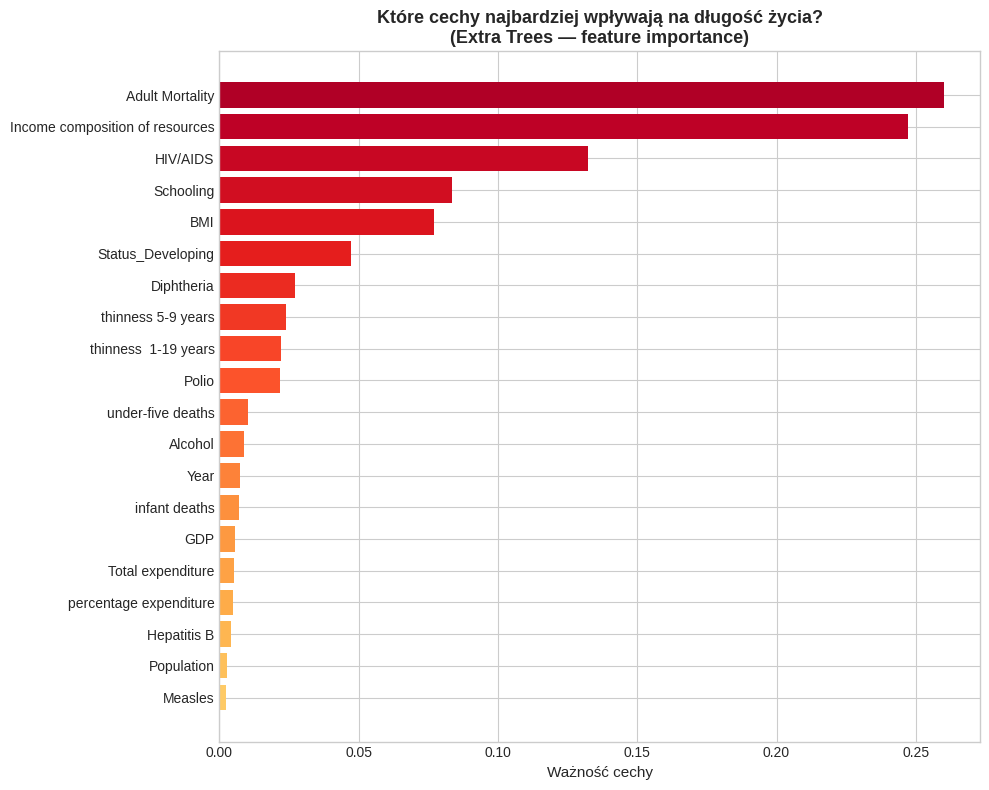

In [119]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(importance_df)))

ax.barh(importance_df['Cecha'][::-1],
        importance_df['Ważność'][::-1],
        color=colors)

ax.set_xlabel('Ważność cechy', fontsize=11)
ax.set_title('Które cechy najbardziej wpływają na długość życia?\n(Extra Trees — feature importance)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

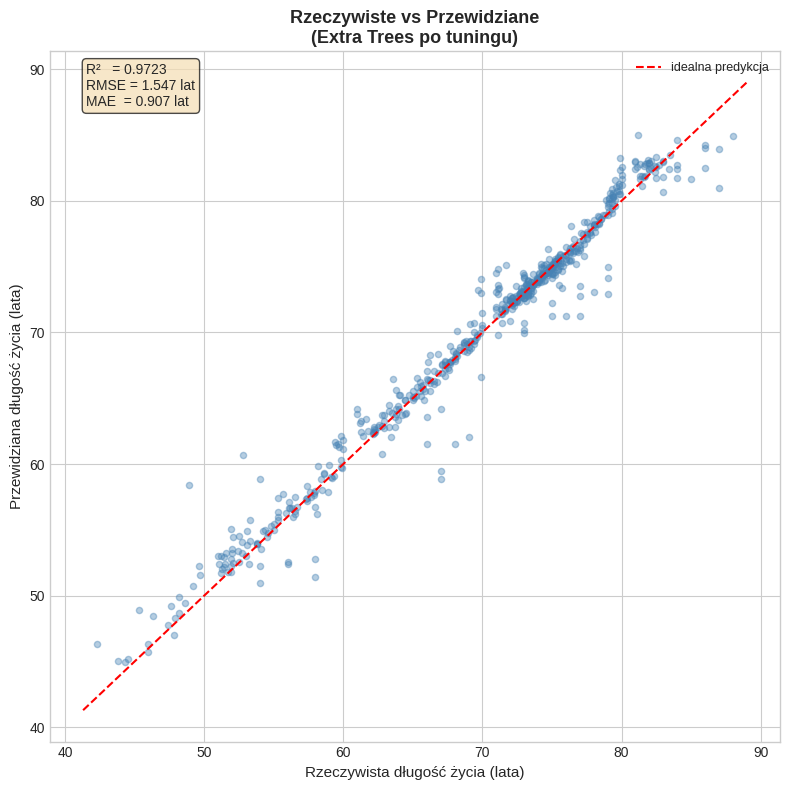

In [120]:
y_pred_tuned = search.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, y_pred_tuned, alpha=0.4, s=20, color='steelblue')

mn, mx = y_test.min() - 1, y_test.max() + 1
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='idealna predykcja')

ax.set_xlabel('Rzeczywista długość życia (lata)', fontsize=11)
ax.set_ylabel('Przewidziana długość życia (lata)', fontsize=11)
ax.set_title('Rzeczywiste vs Przewidziane\n(Extra Trees po tuningu)',
             fontsize=13, fontweight='bold')

ax.text(0.05, 0.92,
        f'R²   = {r2_score(y_test, y_pred_tuned):.4f}\n'
        f'RMSE = {mean_squared_error(y_test, y_pred_tuned)**0.5:.3f} lat\n'
        f'MAE  = {mean_absolute_error(y_test, y_pred_tuned):.3f} lat',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

ax.legend(fontsize=9)
plt.tight_layout()
plt.show()